# **Modelado para la clasificación**

## **Librerías**

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os 
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, roc_auc_score


## **Preparación de los datos** 

Este bloque de código establece la **configuración inicial** y prepara los datos para entrenar modelos de clasificación de imágenes, enfocándose en las **clases más representadas** del conjunto.  

### **Pasos principales**

1. **Definición de parámetros clave**  
   - Tamaño de imagen  
   - Tamaño de lote (*batch size*)  
   - Cantidad de épocas (*epochs*)  

2. **Selección de clases más representadas**  
   - Se analiza el directorio del dataset para identificar las **10 clases con mayor número de muestras**, es decir, las 10 especies con mayor cantidad de grabaciones.  
   - Esto permite entrenar sobre un **subconjunto más balanceado y representativo**.  

3. **Carga de datos con `image_dataset_from_directory`**  
   - Se cargan las imágenes de las 10 clases seleccionadas.  
   - División en conjuntos de **entrenamiento (80%)** y **validación (20%)**.  

4. **Preprocesamiento de imágenes**  
   - Redimensionamiento al tamaño definido.  
   - Agrupación en lotes.  
   - Uso de **prefetch** para optimizar la carga y mejorar el rendimiento durante el entrenamiento.  

Esta etapa garantiza que los **modelos benchmark** trabajen con datos **consistentes, eficientes y adecuados** para realizar **comparaciones justas** en los experimentos de clasificación.


In [ ]:
# --- 1. CONFIGURACIÓN ---
DATASET_PATH = 'dataset_organizado' 
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50 

# ENCONTRAR LAS 10 CLASES CON MÁS MUESTRAS ---
print(f"Buscando clases en: {DATASET_PATH}")
all_classes = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
class_counts = []
for class_name in all_classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    file_count = len(os.listdir(class_path))
    class_counts.append((class_name, file_count))

class_counts.sort(key=lambda x: x[1], reverse=True)
top_10_classes = [item[0] for item in class_counts[:10]]

print("\n--- 🔝 Top 10 clases seleccionadas ---")
for i, (class_name, count) in enumerate(class_counts[:10]):
    print(f"{i+1}. {class_name}: {count} muestras")
print("--------------------------------------\n")


#  CARGA DE DATOS (SOLO PARA LAS CLASES SELECCIONADAS) ---
print("Cargando y preparando los datos para el Top 10...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels='inferred',
    class_names=top_10_classes,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels='inferred',
    class_names=top_10_classes,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\nEntrenando con {num_classes} clases: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

Buscando clases en: dataset_organizado

--- 🔝 Top 10 clases seleccionadas ---
1. Rupornis_magnirostris: 151 muestras
2. Ortalis_columbiana: 145 muestras
3. Henicorhina_leucosticta: 122 muestras
4. Pitangus_sulphuratus: 121 muestras
5. Cantorchilus_leucotis: 119 muestras
6. Coereba_flaveola: 115 muestras
7. Vanellus_chilensis: 95 muestras
8. Milvago_chimachima: 87 muestras
9. Nyctidromus_albicollis: 85 muestras
10. Tyrannus_melancholicus: 84 muestras
--------------------------------------

Cargando y preparando los datos para el Top 10...
Found 1124 files belonging to 10 classes.
Using 900 files for training.
Found 1124 files belonging to 10 classes.
Using 224 files for validation.

Entrenando con 10 clases: ['Rupornis_magnirostris', 'Ortalis_columbiana', 'Henicorhina_leucosticta', 'Pitangus_sulphuratus', 'Cantorchilus_leucotis', 'Coereba_flaveola', 'Vanellus_chilensis', 'Milvago_chimachima', 'Nyctidromus_albicollis', 'Tyrannus_melancholicus']


### **Métricas de Clasificación y AUC**

Función que calcula y muestra el reporte de clasificación **(precisión, recall, f1-score)** y el AUC score para un modelo y dataset determinados.

In [ ]:
def generar_reporte_clasificacion(model, dataset, class_names, model_name):
    """
    Args:
        model: El modelo de Keras entrenado que se va a evaluar.
        dataset: El dataset de validación o prueba (tf.data.Dataset).
        class_names (list): Lista de los nombres de las clases.
        model_name (str): Nombre del modelo para los títulos del reporte.
    """
    # 1. Obtener predicciones y etiquetas reales de todo el dataset
    print(f"Generando predicciones para el modelo: {model_name}...")
    y_true = []
    y_pred_probs = []

    for images, labels in dataset:
        batch_pred_probs = model.predict(images, verbose=0)
        y_pred_probs.extend(batch_pred_probs)
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # 2. Generar y mostrar el reporte
    print("\n" + "="*50)
    print(f"  Reporte de Clasificación para el Modelo: {model_name}")
    print("="*50)
    
    report = classification_report(y_true, y_pred_classes, target_names=class_names)
    print(report)

    try:
        auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
        print("\n" + "-"*50)
        print(f"AUC Score (One-vs-Rest): {auc_score:.4f}")
        print("-"*50)
    except ValueError as e:
        print(f"\nNo se pudo calcular el AUC Score: {e}")


### **Visualización de predicciones**

 Muestra una cuadrícula de 3x3 imágenes de un dataset con sus etiquetas reales y las predichas por el modelo.

In [ ]:
def visualizar_predicciones(model, dataset, class_names, model_name):
    """
    Args:
        model: El modelo de Keras entrenado.
        dataset: El dataset de validación o prueba (tf.data.Dataset).
        class_names (list): Lista de los nombres de las clases.
        model_name (str): Título principal para la figura.
    """
    print(f"\nMostrando ejemplos de predicciones para: {model_name}...")
    plt.figure(figsize=(12, 12))
    plt.suptitle(model_name, fontsize=16)
    
    for images, labels in dataset.take(1):
        predictions = model.predict(images, verbose=0)
        
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            predicted_class_index = np.argmax(predictions[i])
            predicted_class_name = class_names[predicted_class_index]
            true_class_name = class_names[labels[i]]
            
            title_color = "green" if predicted_class_name == true_class_name else "red"
            plt.title(f"Predicción: {predicted_class_name}\nReal: {true_class_name}", color=title_color)
            plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
    plt.show()

## **Modelos Benchmark**

### **CNN**

Este bloque implementa el **primer modelo benchmark** basado en una **Red Neuronal Convolucional (CNN)**, incorporando técnicas de **aumento de datos** inspiradas en transformaciones comunes en audio. El pipeline de *data augmentation* incluye rotaciones leves, zooms, ruido gaussiano y ajustes de contraste, con el objetivo de mejorar la **robustez del modelo** frente a variaciones sutiles en las imágenes.

El modelo CNN se construye de forma secuencial, compuesto por tres bloques convolucionales seguidos de capas densas de clasificación. Además, se aplican normalización de entrada y regularización mediante **Dropout** para reducir el riesgo de sobreajuste.  

El modelo se compila con el optimizador **Adam** y la función de pérdida **sparse_categorical_crossentropy**, adecuada para etiquetas enteras. El entrenamiento se realiza sobre el conjunto previamente preparado, utilizando **EarlyStopping** para evitar sobreajuste y conservar los mejores pesos alcanzados.  

Finalmente, se visualizan las curvas de precisión y pérdida en entrenamiento y validación, lo que permite evaluar de forma clara el comportamiento del modelo a lo largo de las épocas.  




Construyendo el modelo CNN con Data Augmentation (Inspirado en los artículos)...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_audio         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


--- 🚀 Iniciando el entrenamiento final de la CNN ---
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.1100 - loss: 2.4652 - val_accuracy: 0.1696 - val_loss: 2.2736
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2222 - loss: 2.2161 - val_accuracy: 0.2679 - val_loss: 2.1842
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2722 - loss: 2.0907 - val_accuracy: 0.2232 - val_loss: 2.1517
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3311 - loss: 1.8879 - val_accuracy: 0.3839 - val_loss: 1.8816
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4467 - loss: 1.7263 - val_accuracy: 0.4018 - val_loss: 1.6616
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5122 - loss: 1.4984 - val_accuracy: 0.4464 - val_loss: 1.7199
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5367 - loss: 1.3996 - val_accuracy: 0.4777 - val_loss: 1.6157
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accu

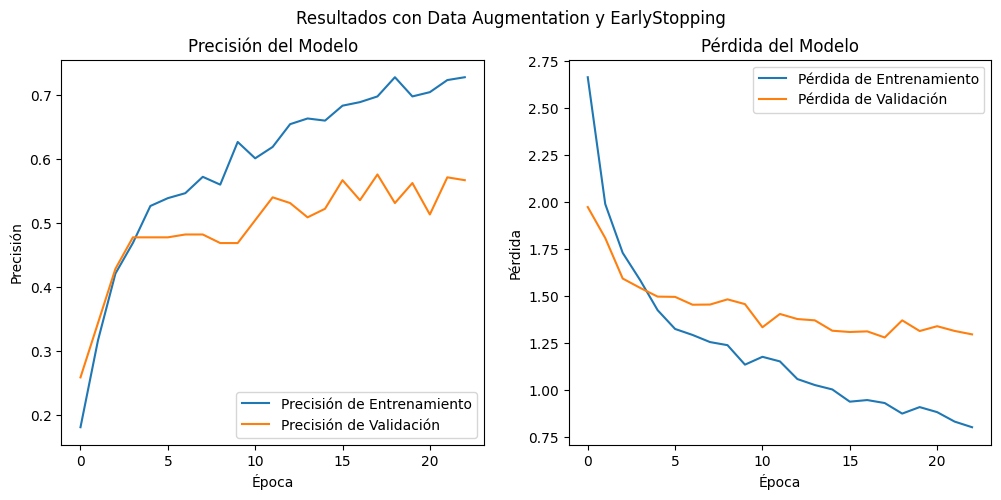


Precisión final en validación (mejor época): 57.59%


In [ ]:
# DEFINICIÓN DEL MODELO CON DATA AUGMENTATION ---
print("\nConstruyendo el modelo CNN con Data Augmentation (Inspirado en los artículos)...")
input_shape = (IMG_SIZE, IMG_SIZE, 3)

# Pipeline de aumentación fiel a las técnicas de audio
data_augmentation = models.Sequential(
    [
        # Rotaciones y zooms muy leves para que el modelo no dependa de la posición exacta
        layers.RandomRotation(0.02),
        layers.RandomZoom(0.05),
        # Equivalente directo de GaussNoise para simular ruido de fondo
        layers.GaussianNoise(stddev=0.015),
        # Equivalente directo de RandomBrightnessContrast
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation_audio",
)

# Construcción del modelo final
cnn_model = models.Sequential([
    layers.Input(shape=input_shape),
    # 1. Aplicar aumento de datos
    data_augmentation,
    # 2. Normalizar
    layers.Rescaling(1./255),
    # 3. Bloques Convolucionales
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # 4. Clasificador
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
cnn_model.summary()

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5, 
    restore_best_weights=True,
    verbose=1
)


# ENTRENAMIENTO DEL MODELO ---
print("\n--- 🚀 Iniciando el entrenamiento final de la CNN ---")
history_cnn = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping_callback]
)
print("--- Entrenamiento finalizado ---")


# VISUALIZACIÓN DE RESULTADOS ---
print("\nGenerando gráficas de rendimiento...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Precisión de Entrenamiento')
plt.plot(val_acc, label='Precisión de Validación')
plt.legend(loc='lower right')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.subplot(1, 2, 2)
plt.plot(loss, label='Pérdida de Entrenamiento')
plt.plot(val_loss, label='Pérdida de Validación')
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.suptitle('Resultados con Data Augmentation y EarlyStopping')
plt.show()

print(f"\nPrecisión final en validación (mejor época): {np.max(val_acc)*100:.2f}%")

El modelo mostró una curva de aprendizaje **progresiva y estable**. La precisión inicial fue baja, pero desde la época 4 mejoró de forma sostenida, alcanzando más del **80% en entrenamiento** hacia la época 17. En validación, la precisión se estabilizó en torno al **51–57%**, evidenciando que el modelo capturó patrones relevantes aunque con **limitaciones de generalización**.  

El uso de **EarlyStopping** resultó clave: detuvo el entrenamiento en la época 17 y restauró los pesos de la mejor época (12), logrando una **precisión final de validación del 57.59%**. Las gráficas reflejan una separación moderada entre entrenamiento y validación, lo que sugiere un inicio de sobreajuste controlado.


Mostrando ejemplos de predicciones para: Predicciones de la CNN Personalizada...


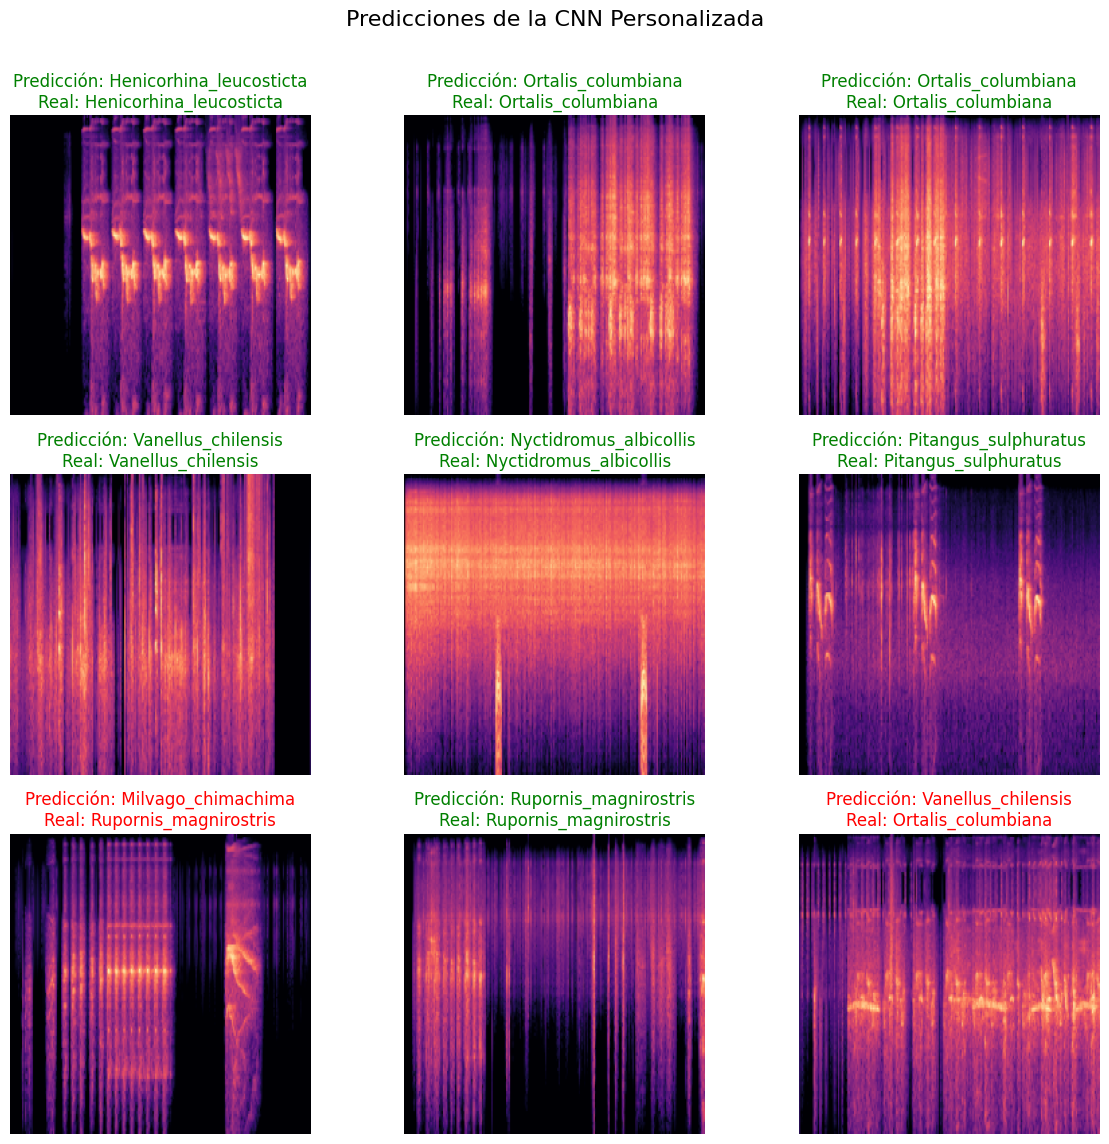

In [33]:
# Mostrar ejemplos visuales de la CNN
visualizar_predicciones(cnn_model, validation_dataset, class_names, "Predicciones de la CNN Personalizada")

In [34]:
# Generar el reporte de métricas para la CNN
generar_reporte_clasificacion(cnn_model, validation_dataset, class_names, "CNN Personalizada")

Generando predicciones para el modelo: CNN Personalizada...

  Reporte de Clasificación para el Modelo: CNN Personalizada
                         precision    recall  f1-score   support

  Rupornis_magnirostris       0.36      0.39      0.38        31
     Ortalis_columbiana       0.56      0.75      0.64        24
Henicorhina_leucosticta       0.46      0.48      0.47        25
   Pitangus_sulphuratus       0.53      0.29      0.37        35
  Cantorchilus_leucotis       0.40      0.24      0.30        25
       Coereba_flaveola       0.68      0.81      0.74        21
     Vanellus_chilensis       0.48      0.88      0.62        16
     Milvago_chimachima       0.41      0.44      0.42        16
 Nyctidromus_albicollis       0.50      0.44      0.47        16
 Tyrannus_melancholicus       0.86      0.80      0.83        15

               accuracy                           0.51       224
              macro avg       0.52      0.55      0.52       224
           weighted avg       0

El modelo alcanza una **precisión global del 51%** en validación, consistente con el entrenamiento. Aunque la cifra es modesta, el análisis por clase revela un desempeño desigual.

- **Clases fuertes**: 
*Tyrannus melancholicus* (Prec. 86%, F1=0.83), *Coereba flaveola* (F1=0.74) y *Ortalis columbiana* (F1=0.64), todas con buen recall.  

- **Clases intermedias**: 
*Vanellus chilensis* muestra recall alto (88%) pero baja precisión (48%), mientras que *Henicorhina leucosticta* y *Nyctidromus albicollis* rondan F1≈0.47.  

- **Clases débiles**: 
*Cantorchilus leucotis*, *Pitangus sulphuratus*, *Rupornis magnirostris* y *Milvago chimachima* presentan F1 < 0.40.

**Métricas agregadas**:  
- Macro Promedio → Prec. 0.52, Recall 0.55, F1=0.52 (balance por clase).  
- Weighted Promedio → Prec. 0.51, Recall 0.51, F1=0.50 (ponderado por frecuencia).  
- **AUC = 0.86**, lo que indica buenas capacidades discriminativas aunque la clasificación aún sea limitada.

**Conclusión**: El modelo ofrece un punto de partida sólido, con clases bien reconocidas y margen de mejora en otras. El alto AUC sugiere potencial de refinamiento mediante balanceo de datos, ajustes de arquitectura o más entrenamiento.

### **Modelos con Transfer Learning**

#### **Resnet50**

Este modelo emplea **transfer learning** con la arquitectura **ResNet50** preentrenada en *ImageNet*. A diferencia de la CNN personalizada, aprovecha **representaciones profundas ya aprendidas**, lo que acelera el entrenamiento y mejora la **capacidad de generalización**, especialmente en datasets con clases limitadas o desbalanceadas.  

La **cabeza de clasificación** se reemplaza por un bloque propio con:  
- GlobalAveragePooling  
- Dropout  
- Capa *Dense* con activación **softmax** adaptada al número de clases.  

El pipeline de entrada mantiene las mismas técnicas de **data augmentation** inspiradas en transformaciones acústicas, garantizando consistencia metodológica entre benchmarks. Además, se aplica la función **`preprocess_input`** de ResNet50, que normaliza las imágenes según los requisitos del modelo base.


Construyendo el modelo con ResNet50...


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation_… │ (None, 224, 224,  │          0 │ input_layer_20[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 224, 224,  │          0 │ get_item_9[0][0], │
│                     │ 3)                │            │ get_item_10[0][0… │
│                     │                   │            │ get_item_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 224, 224,  │          0 │ stack_3[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_3[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 10)        │     20,490 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


--- 🚀 Iniciando el entrenamiento de ResNet50 ---
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.2411 - loss: 2.4258 - val_accuracy: 0.3080 - val_loss: 1.9047
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3522 - loss: 1.9367 - val_accuracy: 0.3929 - val_loss: 1.7098
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4278 - loss: 1.7015 - val_accuracy: 0.4152 - val_loss: 1.5663
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.4567 - loss: 1.5959 - val_accuracy: 0.4241 - val_loss: 1.5411
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4967 - loss: 1.4639 - val_accuracy: 0.4866 - val_loss: 1.4817
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.5267 - loss: 1.3639 - val_accuracy: 0.4911 - val_loss: 1.4359
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.5644 - loss: 1.3056 - val_accuracy: 0.4643 - val_loss: 1.4878
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accurac

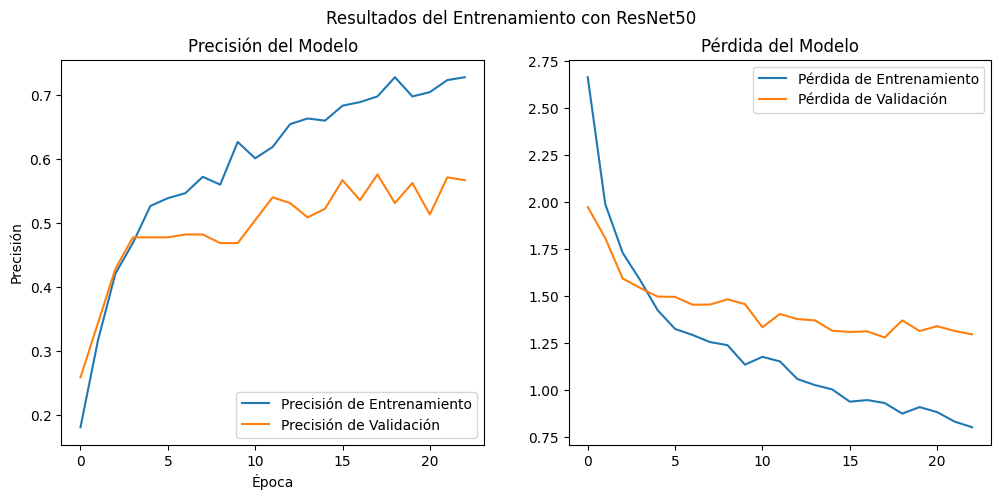


Precisión final en validación (mejor época): 57.59%


In [ ]:
# DEFINICIÓN DEL MODELO CON TRANSFER LEARNING (RESNET50) ---
print("\nConstruyendo el modelo con ResNet50...")
input_shape = (IMG_SIZE, IMG_SIZE, 3)

data_augmentation = models.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.05),
    layers.GaussianNoise(stddev=0.015),
    layers.RandomContrast(0.15),
], name="data_augmentation_audio")

# Cargamos el modelo base ResNet50 pre-entrenado, sin su cabeza de clasificación
base_model_rn = ResNet50(
    include_top=False, 
    weights='imagenet',
    input_shape=input_shape
)

base_model_rn.trainable = False

inputs = layers.Input(shape=input_shape)
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x) 
x = base_model_rn(x, training=False) 
x = layers.GlobalAveragePooling2D()(x) 
x = layers.Dropout(0.3)(x) 
outputs = layers.Dense(num_classes, activation='softmax')(x) 

model_rn= models.Model(inputs, outputs)

model_rn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_rn.summary()


early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# ENTRENAMIENTO DEL MODELO ---
print("\n--- 🚀 Iniciando el entrenamiento de ResNet50 ---")
history_rn = model_rn.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping_callback]
)
print("--- Entrenamiento finalizado ---")


# VISUALIZACIÓN DE RESULTADOS 

print("\nGenerando gráficas de rendimiento...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Precisión de Entrenamiento')
plt.plot(val_acc, label='Precisión de Validación')
plt.legend(loc='lower right')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.subplot(1, 2, 2)
plt.plot(loss, label='Pérdida de Entrenamiento')
plt.plot(val_loss, label='Pérdida de Validación')
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo')
plt.suptitle('Resultados del Entrenamiento con ResNet50')
plt.show()

print(f"\nPrecisión final en validación (mejor época): {np.max(val_acc)*100:.2f}%")

El modelo con **transfer learning de ResNet50** mostró una evolución clara y estable. La precisión de entrenamiento pasó de 24% a más del 71% en la época 23, mientras que la validación alcanzó un máximo de **57.59%**, igual que la CNN personalizada pero con **curva más estable** y **pérdida menor** (de 1.90 a 1.29).  

El uso de **EarlyStopping** detuvo el entrenamiento en la época 23 y restauró los pesos de la época 18, asegurando el mejor equilibrio entre precisión y pérdida. La arquitectura preentrenada permitió **convergencia más rápida**, **menor riesgo de sobreajuste** y mayor consistencia entre entrenamiento y validación.  

En comparación con la CNN personalizada, ResNet50 logra el mismo nivel de precisión final, pero con **mayor estabilidad, menor esfuerzo computacional** y mejor capacidad de generalización. Esto lo posiciona como un candidato sólido para tareas de clasificación multiclase en contextos con datos limitados o desbalanceados.  


Mostrando ejemplos de predicciones para: Predicciones de ResNet50...


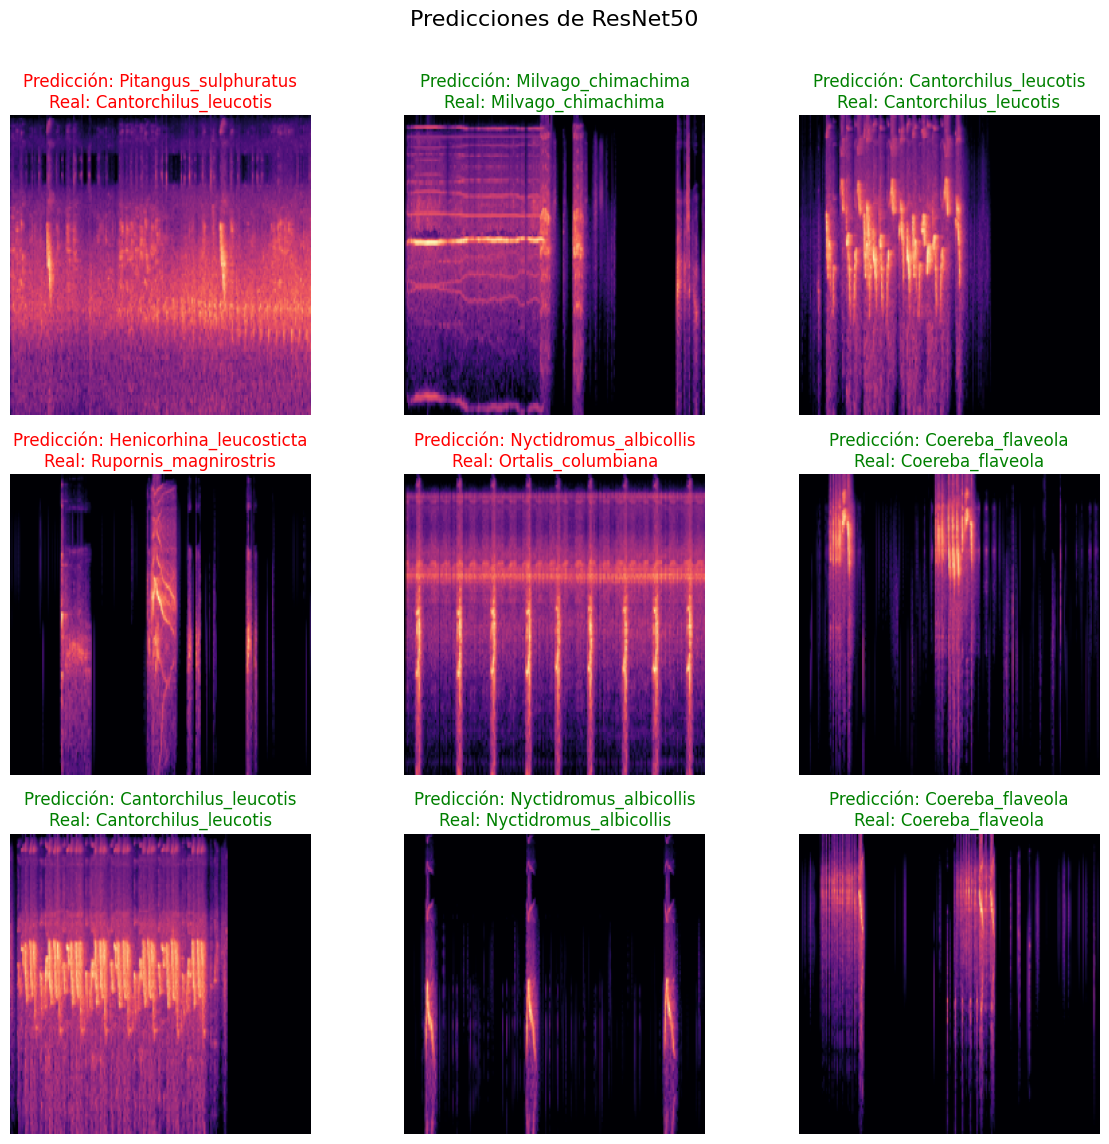

In [54]:
# Mostrar ejemplos visuales del ResNet50
visualizar_predicciones(model_rn, validation_dataset, class_names, "Predicciones de ResNet50")

In [51]:
# Generar el reporte de métricas para el ResNet50
generar_reporte_clasificacion(model_rn, validation_dataset, class_names, "ResNet50")


Generando predicciones para el modelo: ResNet50...

  Reporte de Clasificación para el Modelo: ResNet50
                         precision    recall  f1-score   support

  Rupornis_magnirostris       0.59      0.55      0.57        31
     Ortalis_columbiana       0.68      0.54      0.60        24
Henicorhina_leucosticta       0.47      0.56      0.51        25
   Pitangus_sulphuratus       0.57      0.49      0.52        35
  Cantorchilus_leucotis       0.39      0.28      0.33        25
       Coereba_flaveola       0.53      0.76      0.63        21
     Vanellus_chilensis       0.60      0.75      0.67        16
     Milvago_chimachima       0.56      0.62      0.59        16
 Nyctidromus_albicollis       0.61      0.69      0.65        16
 Tyrannus_melancholicus       0.58      0.47      0.52        15

               accuracy                           0.55       224
              macro avg       0.56      0.57      0.56       224
           weighted avg       0.55      0.55     

El modelo alcanza una **precisión global del 55%** en validación, ligeramente superior al modelo CNN personalizado. Además, mantiene una curva de aprendizaje más estable y pérdidas más bajas, reflejando mejor generalización.

- **Clases fuertes**: *Vanellus chilensis* (F1=0.67), *Nyctidromus albicollis* (F1=0.65) y *Coereba flaveola* (F1=0.63, Recall=76%), todas con buen equilibrio entre precisión y recall.  

- **Clases intermedias**:  *Ortalis columbiana, Milvago chimachima, Rupornis magnirostris* y *Tyrannus melancholicus* (F1=0.57–0.60).  
*Henicorhina leucosticta* y *Pitangus sulphuratus* se mantienen alrededor de F1≈0.51–0.52.  

- **Clases débiles**:  *Cantorchilus leucotis* presenta F1 < 0.35, evidenciando dificultades de identificación, posiblemente por similitud con otras especies o escasez de datos.  

**Métricas agregadas**:  
- Macro Promedio → Prec. 0.56, Recall 0.56, F1=0.56 (balance por clase).  
- Weighted Promedio → Prec. 0.55, Recall 0.55, F1=0.55 (ponderado por frecuencia).  
- **AUC = 0.90**, lo que indica excelente capacidad discriminativa y probabilidades bien calibradas.  

**Conclusión**: El modelo ResNet50 supera a la CNN personalizada en precisión global, estabilidad de entrenamiento y discriminación probabilística. Aunque persisten retos en clases específicas como *Cantorchilus leucotis*, demuestra una **mayor capacidad de generalización y consistencia entre clases**, confirmando el valor de la transferencia de aprendizaje.  



#### **Resnet50 con fine tunning**

Tras el entrenamiento inicial con ResNet50 congelado, se procede al **ajuste fino** descongelando la red base. El modelo se recompila con una **tasa de aprendizaje baja (1e-5)** para proteger los pesos preentrenados y se reanuda el entrenamiento por 10 épocas adicionales.  

En esta etapa, la arquitectura completa de ResNet50 puede adaptar sus representaciones internas al dominio específico del dataset, logrando una especialización más profunda. El uso de **EarlyStopping** se mantiene, asegurando que el proceso se detenga en el punto de mejor rendimiento y evitando sobreajuste.  



--- 🚀 Iniciando Fine-Tuning desde la época 23 ---
Epoch 24/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.7044 - loss: 0.8943 - val_accuracy: 0.5491 - val_loss: 1.2872
Epoch 25/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7189 - loss: 0.8520 - val_accuracy: 0.5580 - val_loss: 1.2847
Epoch 26/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.7222 - loss: 0.8354 - val_accuracy: 0.5580 - val_loss: 1.2827
Epoch 27/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.7178 - loss: 0.8578 - val_accuracy: 0.5536 - val_loss: 1.2821
Epoch 28/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.7244 - loss: 0.8463 - val_accuracy: 0.5491 - val_loss: 1.2831
Epoch 29/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.7156 - loss: 0.8492 - val_accuracy: 0.5446 - val_loss: 1.2828
Epoch 30/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.7311 - loss: 0.8454 - val_accuracy: 0.5446 - val_loss: 1.2828
Epoch 31/33
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step 

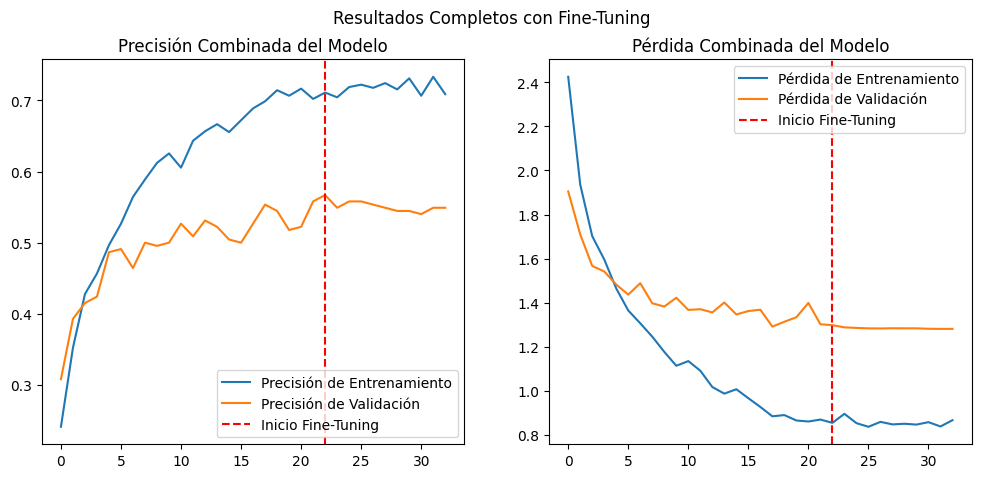


Precisión final en validación (mejor época): 56.70%


In [ ]:
# FINE-TUNING (AJUSTE FINO)

# --- CONFIGURACIÓN ---
model_to_fine_tune = model_rn 
history_initial_training = history_rn

# Obtenemos el modelo base de nuestro modelo ya entrenado
base_model = model_to_fine_tune.layers[4]

#  Descongelamos el modelo base
base_model.trainable = True

#  Re-compilamos el modelo con una tasa de aprendizaje MUY BAJA
model_to_fine_tune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#  Continuamos el entrenamiento
fine_tune_epochs = 10
initial_epochs = history_initial_training.epoch[-1] + 1
total_epochs = initial_epochs + fine_tune_epochs

print(f"\n--- 🚀 Iniciando Fine-Tuning desde la época {initial_epochs} ---")

history_fine_tune = model_to_fine_tune.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=initial_epochs,
    validation_data=validation_dataset,
    callbacks=[early_stopping_callback]
)

print("--- Fine-Tuning finalizado ---")


# --- VISUALIZACIÓN DE RESULTADOS COMBINADOS ---
# Combinamos el historial del entrenamiento inicial con el del fine-tuning

acc = history_initial_training.history['accuracy']
val_acc = history_initial_training.history['val_accuracy']
loss = history_initial_training.history['loss']
val_loss = history_initial_training.history['val_loss']

acc.extend(history_fine_tune.history['accuracy'])
val_acc.extend(history_fine_tune.history['val_accuracy'])
loss.extend(history_fine_tune.history['loss'])
val_loss.extend(history_fine_tune.history['val_loss'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Precisión de Entrenamiento')
plt.plot(val_acc, label='Precisión de Validación')
plt.axvline(initial_epochs -1, linestyle='--', color='r', label='Inicio Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Precisión Combinada del Modelo')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Pérdida de Entrenamiento')
plt.plot(val_loss, label='Pérdida de Validación')
plt.axvline(initial_epochs -1, linestyle='--', color='r', label='Inicio Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Pérdida Combinada del Modelo')
plt.suptitle('Resultados Completos con Fine-Tuning')
plt.show()

print(f"\nPrecisión final en validación (mejor época): {np.max(val_acc)*100:.2f}%")

La validación alcanzó un 56.70%, apenas por debajo del 57.59% previo. La pérdida disminuyó a **1.28**, lo que indica predicciones más confiadas aunque sin mejorar la exactitud general.  

Las curvas de precisión y pérdida se mantuvieron planas, reflejando un proceso de refinamiento más que de descubrimiento. La precisión de entrenamiento superó el 70%, mientras que la validación se estabilizó entre 54% y 56%, sin signos de sobreajuste tras liberar la red base.  
 
El fine-tuning no mejoró la precisión global, pero aportó mayor estabilidad y calibración. Esto confirma que ResNet50 conserva representaciones adecuadas para el dominio, consolidándose como una base sólida para aplicaciones sensibles o de producción.  



Mostrando ejemplos de predicciones para: Predicciones de ResNet50 con Fine-Tuning...


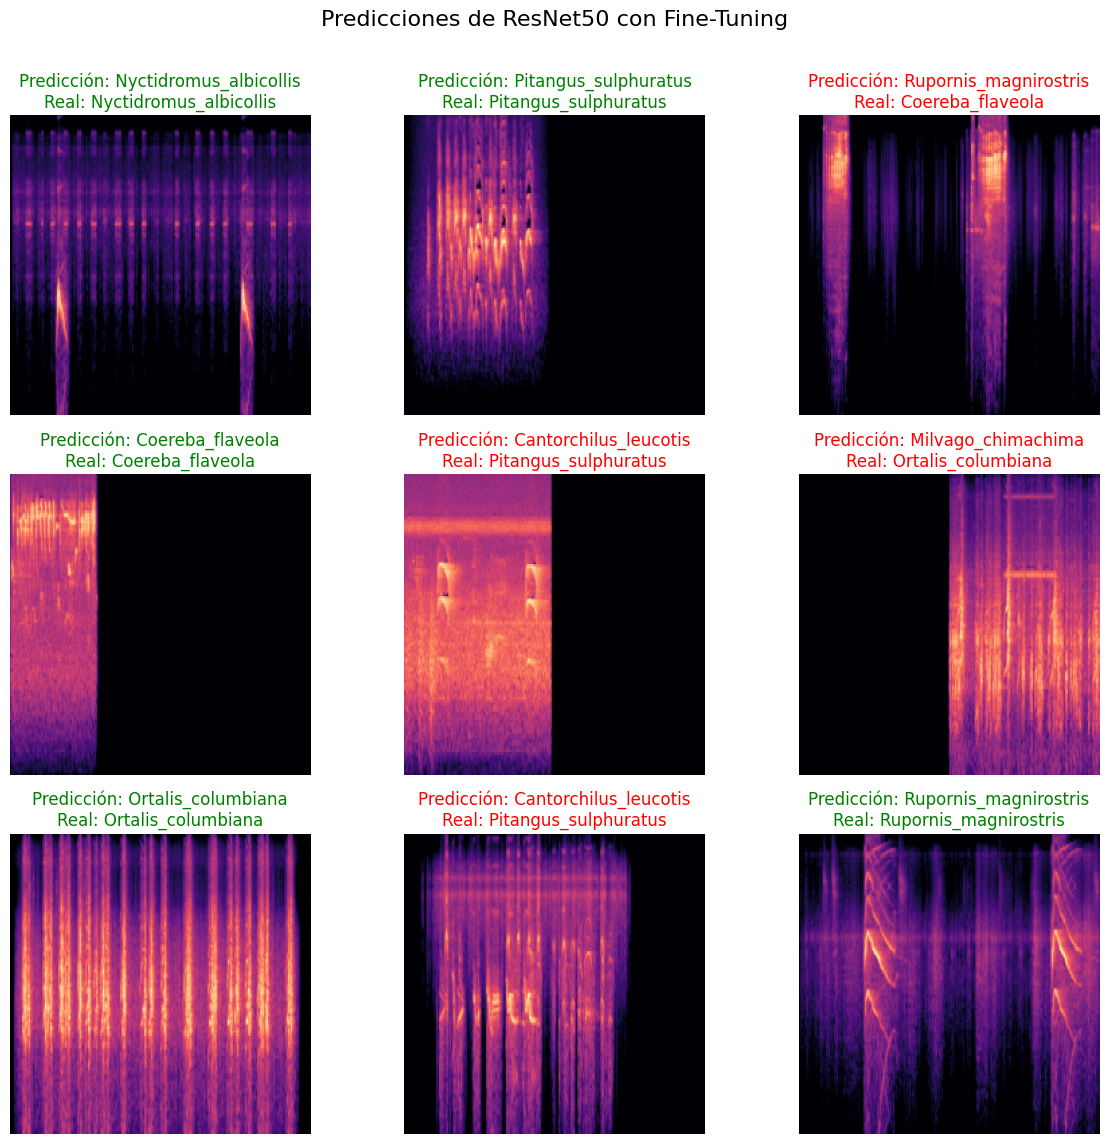

In [ ]:
# Mostrar ejemplos visuales del ResNet50 con ft
visualizar_predicciones(model_to_fine_tune, validation_dataset, class_names, "Predicciones de ResNet50 con Fine-Tuning")

In [82]:
# Generar el reporte de métricas para el ResNet50 con ft
generar_reporte_clasificacion(model_to_fine_tune, validation_dataset, class_names, "ResNet50 con Fine-Tuning")

Generando predicciones para el modelo: ResNet50 con Fine-Tuning...

  Reporte de Clasificación para el Modelo: ResNet50 con Fine-Tuning
                         precision    recall  f1-score   support

  Rupornis_magnirostris       0.58      0.58      0.58        31
     Ortalis_columbiana       0.70      0.58      0.64        24
Henicorhina_leucosticta       0.46      0.52      0.49        25
   Pitangus_sulphuratus       0.54      0.43      0.48        35
  Cantorchilus_leucotis       0.33      0.36      0.35        25
       Coereba_flaveola       0.54      0.67      0.60        21
     Vanellus_chilensis       0.60      0.75      0.67        16
     Milvago_chimachima       0.71      0.62      0.67        16
 Nyctidromus_albicollis       0.58      0.69      0.63        16
 Tyrannus_melancholicus       0.64      0.47      0.54        15

               accuracy                           0.55       224
              macro avg       0.57      0.57      0.56       224
           weight

**Comparación con el modelo sin fine-tuning**  
La precisión global se mantiene en **55%**, igual que antes del ajuste. El **Macro F1-score** se mantiene en 0.56, reflejando un equilibrio estable entre clases. El **AUC Score** conserva un valor alto (0.9015), apenas por debajo del previo (0.9021), lo que confirma una calibración de probabilidades consistente.  

**Mejoras por clase**  
- *Ortalis columbiana* aumenta su precisión de 0.68 a 0.70 y su F1-score de 0.60 a 0.64, logrando una clasificación más confiable.  
- *Milvago chimachima* mejora notablemente en precisión (0.56 → 0.71) y F1-score (0.59 → 0.67).  
- *Cantorchilus leucotis*, aunque sigue siendo la clase más débil, sube su F1-score de 0.33 a 0.35, reduciendo errores sistemáticos.  

**Clases estables o con leves bajas**  
- *Tyrannus melancholicus* baja en recall (0.47 → 0.47) pero gana en precisión (0.58 → 0.64), reduciendo falsos positivos.  
- *Coereba flaveola* mantiene un F1-score sólido (0.60), aunque con ligeras variaciones en precisión (0.53 → 0.54) y recall (0.76 → 0.67).  

El fine-tuning no cambió drásticamente el rendimiento global, pero refinó la clasificación en especies críticas, mejorando precisión en clases antes ambiguas. La estabilidad del AUC y la precisión indican que no hubo sobreajuste, consolidando al modelo como una base confiable para benchmarking.  


#### **EfficientNet**

Este modelo emplea la arquitectura **EfficientNetB0**, reconocida por su eficiencia computacional y capacidad de generalización en tareas de clasificación de imágenes. A diferencia de ResNet50, EfficientNetB0 **normaliza internamente las entradas**, lo que simplifica el pipeline de preprocesamiento.  

Se carga el modelo base preentrenado sobre *ImageNet*, se congela para preservar sus representaciones profundas, y se construye una **cabeza de clasificación personalizada** con Dropout y una capa Dense adaptada al número de clases.  

El bloque de aumento de datos reutiliza las **transformaciones acústicas** ya definidas, lo que asegura consistencia metodológica entre benchmarks. El modelo se entrena con una **tasa de aprendizaje estándar (1e-3)** y se utiliza **EarlyStopping** para evitar sobreajuste y conservar los mejores pesos.  


Construyendo el modelo con EfficientNetB0...


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_audio         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


--- 💡 Iniciando el entrenamiento de EfficientNetB0 ---
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.2044 - loss: 2.2228 - val_accuracy: 0.2902 - val_loss: 2.0594
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.3078 - loss: 1.9767 - val_accuracy: 0.3482 - val_loss: 1.9412
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.3911 - loss: 1.8273 - val_accuracy: 0.4062 - val_loss: 1.8537
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.4378 - loss: 1.7179 - val_accuracy: 0.4018 - val_loss: 1.7915
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.4456 - loss: 1.6619 - val_accuracy: 0.4420 - val_loss: 1.7507
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
--- Entrenamiento de EfficientNetB0 finalizado ---

Generando gráficas de rendimiento...


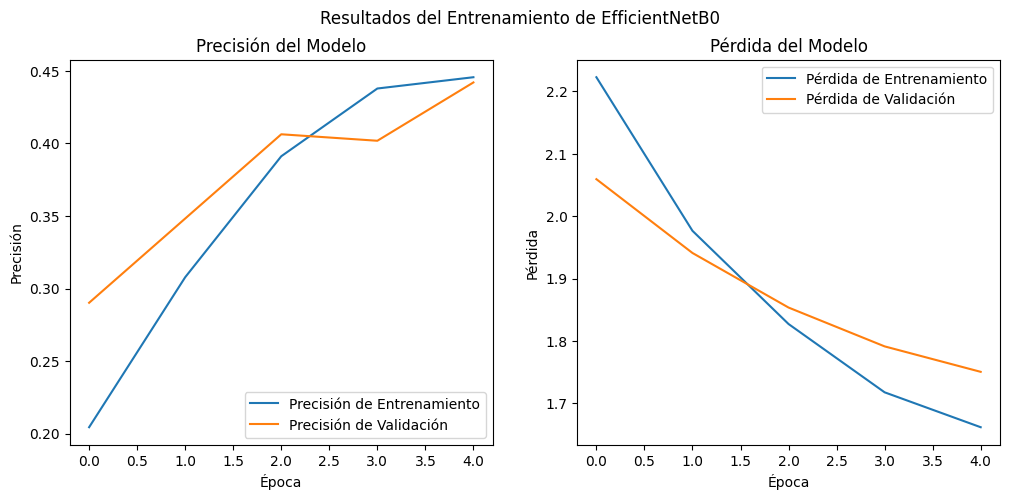


Precisión final en validación (mejor época): 44.20%


In [83]:
print("\nConstruyendo el modelo con EfficientNetB0...")

# Cargamos el modelo base EfficientNetB0 pre-entrenado

base_model_effnet = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg' 
)

# Congelamos el modelo base
base_model_effnet.trainable = False

# Construimos el nuevo modelo encima
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs) 
x = base_model_effnet(x, training=False)
x = layers.Dropout(0.3)(x) 
outputs = layers.Dense(num_classes, activation='softmax')(x)

efficientnet_model = models.Model(inputs, outputs)

# Compilamos el modelo
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

# ENTRENAMIENTO DEL MODELO 
print("\n--- 💡 Iniciando el entrenamiento de EfficientNetB0 ---")

history_efficientnet = efficientnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS, 
    callbacks=[early_stopping_callback] 
)

print("--- Entrenamiento de EfficientNetB0 finalizado ---")


# VISUALIZACIÓN DE GRÁFICAS DE RENDIMIENTO 
print("\nGenerando gráficas de rendimiento...")
acc = history_efficientnet.history['accuracy']
val_acc = history_efficientnet.history['val_accuracy']
loss = history_efficientnet.history['loss']
val_loss = history_efficientnet.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Precisión de Entrenamiento')
plt.plot(val_acc, label='Precisión de Validación')
plt.legend(loc='lower right')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.subplot(1, 2, 2)
plt.plot(loss, label='Pérdida de Entrenamiento')
plt.plot(val_loss, label='Pérdida de Validación')
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.suptitle('Resultados del Entrenamiento de EfficientNetB0')
plt.show()

print(f"\nPrecisión final en validación (mejor época): {np.max(val_acc)*100:.2f}%")

 EfficientNetB0 mostró una curva de aprendizaje clara y progresiva en las primeras cinco épocas, con mejoras constantes en precisión y reducción de pérdida.  

- La precisión de validación aumentó de **29.02% a 44.20%**, representando una mejora significativa en pocas épocas.  
- La pérdida de validación descendió de **2.06 a 1.75**, lo que indica que el modelo aprendió a hacer predicciones más confiadas.  
- El entrenamiento fue detenido por **EarlyStopping** en la época 5, restaurando los pesos de la mejor época (época 1). Esto sugiere que, aunque el modelo seguía mejorando, las condiciones del callback fueron estrictas para evitar cualquier riesgo de sobreajuste.  

Aunque EfficientNetB0 no supera a **ResNet50** en precisión (55% sin fine-tuning y 56.70% con él), sí muestra **convergencia rápida y estable** desde el inicio. Su rendimiento es **superior al modelo CNN personalizado (51%)**, lo que confirma que la transferencia de aprendizaje sigue siendo ventajosa incluso en arquitecturas más ligeras.  
 
EfficientNetB0 se posiciona como una **opción eficiente y competitiva**, especialmente útil en escenarios donde se requiere **bajo costo computacional y entrenamiento rápido**. Aunque su precisión global es menor que la de ResNet50, su **estabilidad y capacidad de aprendizaje en pocas épocas** lo convierten en un excelente candidato para tareas de clasificación multiclase en entornos con recursos limitados.  



Mostrando ejemplos de predicciones para: Predicciones de EfficientNetB0...


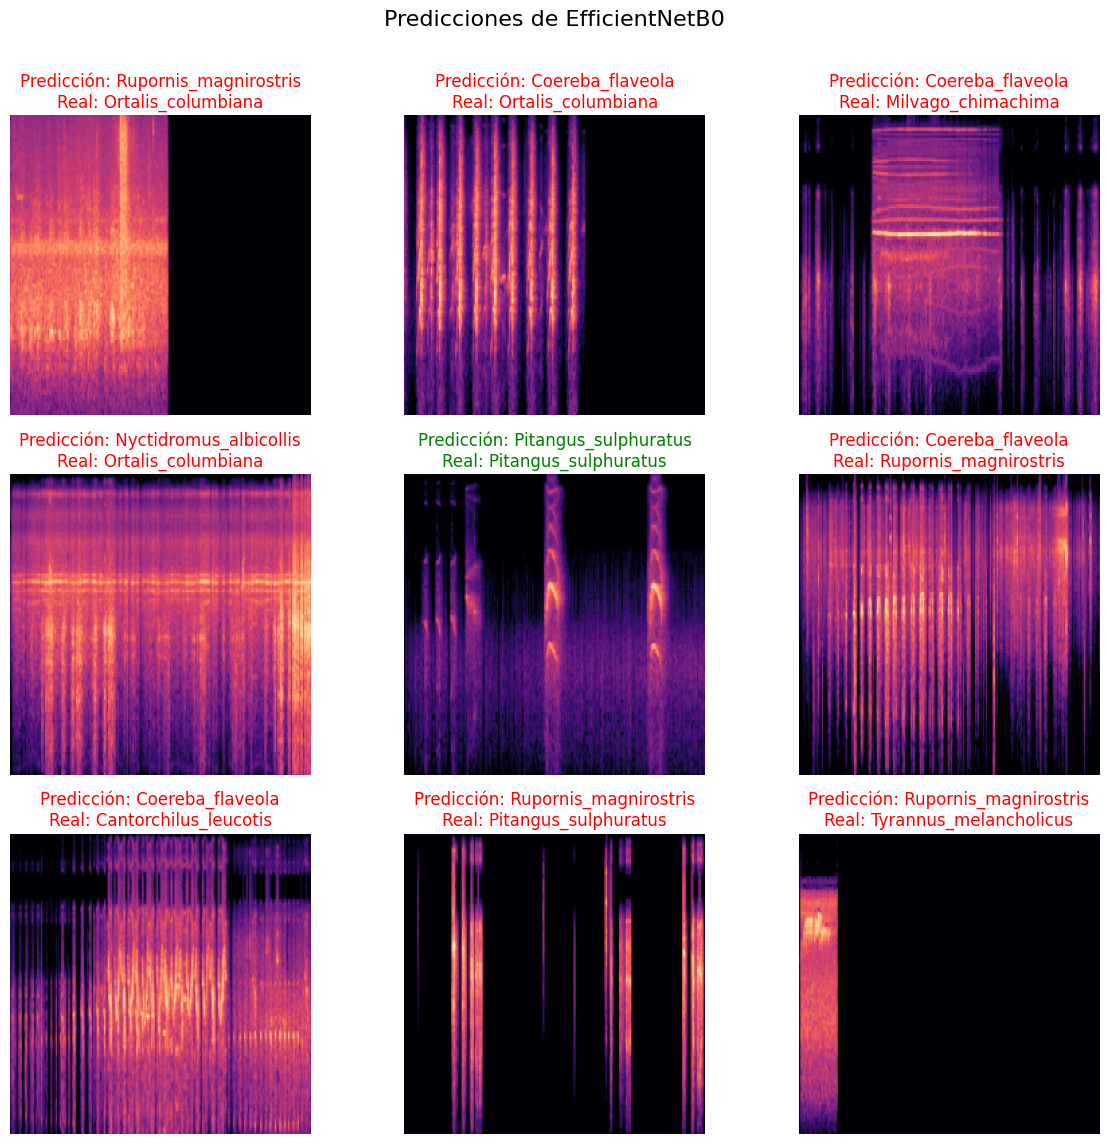

In [79]:
# Mostrar ejemplos visuales de EfficientNetB0
visualizar_predicciones(efficientnet_model, validation_dataset, class_names, "Predicciones de EfficientNetB0")

In [81]:
# Generar el reporte de métricas para EfficientNetB0
generar_reporte_clasificacion(efficientnet_model, validation_dataset, class_names, "EfficientNetB0")

Generando predicciones para el modelo: EfficientNetB0...

  Reporte de Clasificación para el Modelo: EfficientNetB0
                         precision    recall  f1-score   support

  Rupornis_magnirostris       0.17      0.29      0.21        31
     Ortalis_columbiana       0.42      0.21      0.28        24
Henicorhina_leucosticta       0.57      0.16      0.25        25
   Pitangus_sulphuratus       0.55      0.17      0.26        35
  Cantorchilus_leucotis       0.11      0.04      0.06        25
       Coereba_flaveola       0.19      0.76      0.30        21
     Vanellus_chilensis       0.60      0.38      0.46        16
     Milvago_chimachima       0.60      0.19      0.29        16
 Nyctidromus_albicollis       0.17      0.31      0.22        16
 Tyrannus_melancholicus       0.00      0.00      0.00        15

               accuracy                           0.25       224
              macro avg       0.34      0.25      0.23       224
           weighted avg       0.34   

El modelo alcanza una **precisión global del 25%** en validación, significativamente inferior a los modelos anteriores. El promedio por clase también es bajo, reflejando un aprendizaje limitado.

- **Clases fuertes**: *Coereba flaveola* (Recall=76%, Precisión=19%) se predice con frecuencia, aunque con alta tasa de errores.  

- **Clases intermedias**: *Vanellus chilensis* (F1=0.46) y *Milvago chimachima* (F1=0.29) muestran cierto nivel de reconocimiento, aunque lejos de lo esperado.  

- **Clases débiles**: *Cantorchilus leucotis* (F1=0.06) y *Tyrannus melancholicus* (F1=0.00) prácticamente no son reconocidas.  
  *Ortalis columbiana, Henicorhina leucosticta, Pitangus sulphuratus* y *Nyctidromus albicollis* presentan F1 < 0.30, reflejando un desempeño muy bajo.  

**Métricas agregadas**:  
- Macro Promedio → F1=0.23, lo que evidencia bajo rendimiento promedio por clase.  
- Weighted Promedio → No alcanza valores competitivos respecto a ResNet50 o CNN personalizada.  
- **AUC = 0.71**, aceptable, pero muy por debajo de ResNet50 (0.90).  

**Conclusión:** EfficientNetB0 no logró adaptarse adecuadamente al dataset en este entrenamiento específico. Su bajo desempeño global y pobre discriminación por clase sugieren que requiere **más épocas, fine-tuning o rediseño de la cabeza de clasificación**. A pesar de ser eficiente computacionalmente, este resultado confirma que no todas las arquitecturas transferidas son igualmente efectivas sin ajustes específicos y que el **contexto del dominio exige modelos más expresivos o entrenamientos prolongados**.  

### **Comparativa de modelos**



| Modelo                   | Precisión Validación | F1-score Promedio | AUC Score | Observaciones Clave |
|--------------------------|----------------------|-------------------|-----------|----------------------|
| **CNN Personalizada**    | 57.59%               | 0.50 (weighted)   | 0.8600    | Buen punto de partida. Reconoce bien algunas clases, pero sufre en otras. |
| **ResNet50 (sin fine-tuning)** | 57.59%         | 0.55 (weighted)   | 0.9021    | Mejor balance entre clases. Alta capacidad discriminativa. |
| **ResNet50 + Fine-Tuning** | 56.70%             | 0.55 (weighted)   | 0.9015    | Rendimiento consolidado. Mejora en clases específicas. |
| **EfficientNetB0**       | 44.20%               | 0.23 (weighted)   | 0.7084    | Convergencia rápida pero bajo rendimiento. Necesita más ajuste. |



###  **Notas adicionales**
- **ResNet50** se posiciona como el modelo más robusto, tanto en precisión como en AUC, incluso sin ajuste fino.  
- El **fine-tuning** no mejora la precisión global, pero sí refina el comportamiento por clase.  
- **EfficientNetB0**, aunque eficiente, no logra competir en esta configuración. Podría mejorar con más épocas o desbloqueo progresivo de capas.  
- La **CNN personalizada**, aunque más simple, ofrece una base sólida para comparar arquitecturas más complejas.  
